In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append('/home/future_commodity')
import os
import re
from pathlib import Path
from typing import List, Tuple

import numpy as np
np.seterr(all='ignore')
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed

import function_future.pre_train as pt
import function_future.train_model as tm
import function_future.FactorFilter as FF
import function_future.backtest_v3 as bv
import function_future.DataLoader as DL
import function_future.date_selection as DS
import function_future.trading_visualization as TV
from function_future.margin_calculator import calculate_margin, get_instrument_info, get_first_trade_date, get_recent_activity

In [17]:
symbol_lst = ["RU", "BR", "NR", "L", "TA", "PF", "V", "EG", "MA", "PP", "EB", "UR", "SA", "SH", "PX", "PR"]

In [18]:
init_money_lst = []
for symbol in symbol_lst:
    margin = calculate_margin(symbol, 10)
    info = get_instrument_info(symbol)
    first_date = get_first_trade_date(symbol)
    activity = get_recent_activity(symbol)
    print(f"\n品种: {symbol} ({info.get('name', 'N/A')})")
    print(f"  首个交易日: {first_date}")
    print(f"  95分位数价格: {info['price_95th']:.2f}")
    print(f"  合约乘数: {info['contract_multiplier']}")
    print(f"  保证金率: {info['margin_rate']:.2%}")
    print(f"  10手保证金: {margin:,.2f} 元")
    print(f"  40%保证金所需本金: {margin / 0.4:,.0f} 元")
    # print(f"  交易所: {info['exchange']}")
    print(f"  分均持仓量: {activity['avg_open_interest']:,.0f}")
    print(f"  分均成交量: {activity['avg_volume']:,.0f}")
    print(f"  分均成交额: {activity['avg_turnover']:,.0f} 元")
    init_money_lst.append(int(margin / 0.4))


品种: RU (天然橡胶)
  首个交易日: 2021-02-08
  95分位数价格: 17035.00
  合约乘数: 10
  保证金率: 10.00%
  10手保证金: 170,350.00 元
  40%保证金所需本金: 425,875 元
  分均持仓量: 149,486
  分均成交量: 933
  分均成交额: 142,774,281 元

品种: BR (合成橡胶)
  首个交易日: 2023-07-28
  95分位数价格: 13670.00
  合约乘数: 10
  保证金率: 11.00%
  10手保证金: 150,370.00 元
  40%保证金所需本金: 375,925 元
  分均持仓量: 56,434
  分均成交量: 325
  分均成交额: 19,272,167 元

品种: NR (20号胶)
  首个交易日: 2021-06-17
  95分位数价格: 14470.00
  合约乘数: 10
  保证金率: 11.00%
  10手保证金: 159,170.00 元
  40%保证金所需本金: 397,925 元
  分均持仓量: 60,112
  分均成交量: 258
  分均成交额: 33,020,504 元

品种: L (塑料)
  首个交易日: 2021-02-02
  95分位数价格: 7702.00
  合约乘数: 5
  保证金率: 7.00%
  10手保证金: 26,957.00 元
  40%保证金所需本金: 67,392 元
  分均持仓量: 407,941
  分均成交量: 751
  分均成交额: 26,675,611 元

品种: TA (PTA)
  首个交易日: 2021-02-01
  95分位数价格: 5300.00
  合约乘数: 5
  保证金率: 7.00%
  10手保证金: 18,550.00 元
  40%保证金所需本金: 46,375 元
  分均持仓量: 1,131,266
  分均成交量: 3,136
  分均成交额: 76,415,381 元

品种: PF (短纤)
  首个交易日: 2021-02-01
  95分位数价格: 6734.00
  合约乘数: 5
  保证金率: 7.00%
  10手保证金: 23,569.00 元
  40%保证金所需本金:

In [19]:
initial_capital = dict(zip(symbol_lst, init_money_lst))
initial_capital

{'RU': 425875,
 'BR': 375925,
 'NR': 397925,
 'L': 67392,
 'TA': 46375,
 'PF': 58922,
 'V': 45080,
 'EG': 78627,
 'MA': 51020,
 'PP': 63822,
 'EB': 69652,
 'UR': 75040,
 'SA': 63944,
 'SH': 161160,
 'PX': 74600,
 'PR': 164220}

In [20]:
weights = dict(zip(symbol_lst, [5_000_000 // x for x in init_money_lst]))
weights

{'RU': 11,
 'BR': 13,
 'NR': 12,
 'L': 74,
 'TA': 107,
 'PF': 84,
 'V': 110,
 'EG': 63,
 'MA': 98,
 'PP': 78,
 'EB': 71,
 'UR': 66,
 'SA': 78,
 'SH': 31,
 'PX': 67,
 'PR': 30}

In [21]:
train_label = 5
rtn_mul = 1

bt_params = (0.8, 0.5, 10, 5*345)
train_end_date = '2025-07-01'

In [22]:
def run_res(symbol, bt_params):
    folder_name = f'{symbol}_pred{train_label}_{train_end_date}_v0'

    config_loader = DL.InstrumentConfig()
    config_loader.get_instrument_config(symbol)

    config = bv.load_config(r"/mnt/Data/writable/liaoyuyang/backtest/backtest_config.json")
    config['MODEL_DIR'] = Path(config['MODEL_DIR']) / str(folder_name)
    config['symbol'] = symbol
    # print(config)

    bt = bv.ModelBacktester(train_end_date, config)
    bt.load_config(symbol)
    bt.window_end = '2027-01-01'
    bt.money = initial_capital[symbol]
    bt.fee = 0

    bt.load_factor(symbol, end_date=bt.window_end)
    bt.load_mktdata(symbol, end_date=bt.window_end)
    bt.load_models()
    bt.generate_predictions()
    pred = bt.combine_models('best_iteration_log_weighted', avg=True)

    th1, th2, holding_bars, day = bt_params
    merged_data = bt.backtest(th1=th1, th2=th2, save=False, open_drop=True, holding_bars=holding_bars,
                           day=day, model_name='best_iteration_log_weighted', v=2
                        )

    return merged_data

In [ ]:
merged_data_lst = Parallel(n_jobs=len(symbol_lst))(delayed(run_res)(symbol, bt_params)
                                                   for symbol in symbol_lst)

In [ ]:
def plot_all(symbol_lst, merged_data_lst, weights=None):
    pnl_ret = []
    for i, merged_data in enumerate(merged_data_lst):
        symbol = symbol_lst[i]
        df = merged_data.set_index('datetime')[['equity', 'date']]
        df.rename(columns={'equity':symbol}, inplace=True)
        df = df.groupby('date').last()
        # 如果有权重配置，应用权重
        if weights and symbol in weights:
            df[symbol] = df[symbol] * weights[symbol]

        df = df.iloc[:-30]

        pnl_ret.append(df)

    return pd.concat(pnl_ret,axis=1).ffill()

In [ ]:
merged_df_all = plot_all(symbol_lst, merged_data_lst, weights=weights)
merged_df_all

,RU,BR,NR,L,TA,PF,V,EG,MA,PP,EB,UR,SA,SH,PX,PR
date,,,,,,,,,,,,,,,,
2025-07-01,4.731226e+06,4.755659e+06,4.774391e+06,4.959772e+06,4.942420e+06,4.639429e+06,5.029151e+06,4.905397e+06,5.133996e+06,4.904866e+06,5.150425e+06,4.849480e+06,5.071416e+06,4.949809e+06,5.148348e+06,5.095734e+06
2025-07-02,4.633953e+06,4.987528e+06,4.679283e+06,5.088663e+06,4.864932e+06,4.813068e+06,5.488716e+06,4.804847e+06,5.254729e+06,4.970315e+06,5.455344e+06,4.675466e+06,5.046304e+06,5.161991e+06,5.516195e+06,5.088505e+06
2025-07-03,4.630944e+06,4.915508e+06,4.739169e+06,5.205916e+06,4.626616e+06,4.657818e+06,5.539263e+06,4.764573e+06,5.292264e+06,4.961861e+06,5.420340e+06,4.955454e+06,5.581294e+06,5.296650e+06,5.411990e+06,4.948487e+06
2025-07-04,4.543009e+06,4.935556e+06,4.630385e+06,5.231876e+06,4.416028e+06,4.592306e+06,5.194740e+06,4.918203e+06,5.535338e+06,4.970683e+06,5.097297e+06,5.284345e+06,5.402886e+06,5.132502e+06,5.703213e+06,5.099330e+06
2025-07-07,4.546016e+06,4.722043e+06,4.793333e+06,5.158914e+06,4.476181e+06,4.485955e+06,5.123450e+06,5.033725e+06,5.332302e+06,4.981835e+06,4.988842e+06,5.406483e+06,5.467271e+06,4.970363e+06,5.656486e+06,5.016084e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-09,5.076749e+06,8.539923e+06,5.926196e+06,8.815073e+06,5.255928e+06,6.452456e+06,6.727618e+06,6.156991e+06,7.756924e+06,5.522821e+06,9.050012e+06,8.234133e+06,1.273056e+07,5.555648e+06,5.295300e+06,1.130179e+07
2026-01-12,5.076749e+06,8.539923e+06,5.926196e+06,8.815073e+06,5.255928e+06,6.465877e+06,6.727618e+06,6.156991e+06,7.756924e+06,5.522821e+06,9.050012e+06,8.234133e+06,1.273056e+07,5.555648e+06,5.295300e+06,1.130179e+07
2026-01-13,5.076749e+06,8.539923e+06,5.926196e+06,8.815073e+06,5.255928e+06,6.611857e+06,6.727618e+06,6.156991e+06,7.756924e+06,5.522821e+06,9.050012e+06,8.234133e+06,1.273056e+07,5.555648e+06,5.295300e+06,1.130179e+07


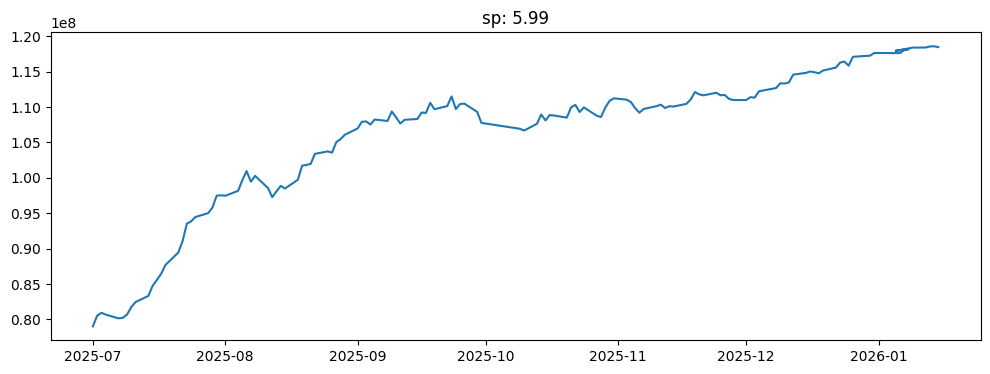

In [ ]:
sp = merged_df_all.sum(axis=1).diff().mean() / merged_df_all.sum(axis=1).diff().std() * np.sqrt(252)
plt.figure(figsize=(12, 4))  # Correct way to set figure size
plt.plot(merged_df_all.sum(axis=1))
plt.title(f'sp: {round(sp,2)}')
plt.show()

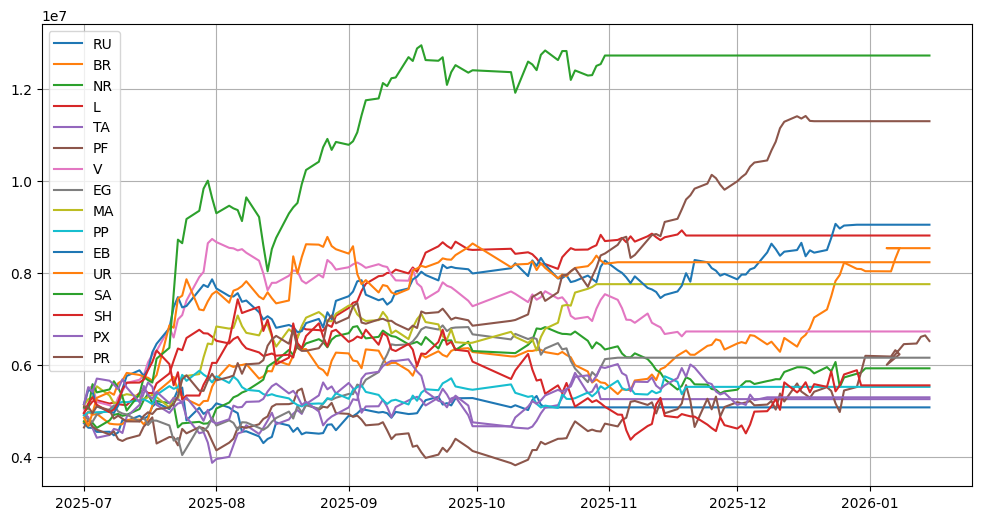

In [ ]:
fig = plt.figure(figsize=(12, 6))
plt.plot(merged_df_all)
plt.legend(symbol_lst)
plt.grid()
plt.show()

In [ ]:
res = pd.concat((bv.analyze_pos_distribution(merged_data_lst[i]) for i in range(len(symbol_lst))), axis=1)
res.columns = symbol_lst
res.T

,多头(+1) 数量,空头(-1) 数量,空仓(0) 数量,多头占比,空头占比,空仓占比,交易日数量,总收益(非年化%),总交易次数（开平算一次）,日均交易次数（开平算一次）,每笔收益(%%),年化日度夏普,最大回撤(%),年化卡玛比率,最赚钱的一天,最亏钱的一天
RU,9443,17286,8686,26.66%,48.81%,24.53%,104,29.95,1524,14.65,1.97,1.42,-21.94,3.34,2025-10-31,2025-07-25
BR,21102,21336,12057,38.72%,39.15%,22.12%,160,61.32,2314,14.46,2.65,1.66,-26.14,3.72,2026-02-10,2026-01-26
NR,14943,23004,15393,28.01%,43.13%,28.86%,157,67.04,2026,12.90,3.31,2.33,-21.38,5.07,2026-01-14,2025-12-25
L,16941,17777,8507,39.19%,41.13%,19.68%,127,53.10,1764,13.89,3.01,2.34,-25.59,4.15,2025-08-20,2025-12-08
TA,15528,15340,7642,40.32%,39.83%,19.84%,113,38.69,1576,13.95,2.45,1.40,-31.12,2.80,2025-11-07,2025-10-27
PF,21906,21900,12749,38.73%,38.72%,22.54%,166,82.96,2027,12.21,4.09,1.64,-30.41,4.17,2026-03-02,2026-02-04
V,15860,17346,10019,36.69%,40.13%,23.18%,127,38.41,1382,10.88,2.78,1.26,-29.22,2.63,2025-07-30,2025-12-12
EG,3363,18888,16959,8.58%,48.17%,43.25%,115,54.90,1217,10.58,4.51,2.48,-21.08,5.76,2025-07-28,2025-07-24
MA,16169,16347,5649,42.37%,42.83%,14.80%,112,78.01,2611,23.31,2.99,3.06,-13.37,13.24,2025-10-30,2025-11-19
PP,16389,15885,10951,37.92%,36.75%,25.33%,127,1.95,1359,10.70,0.14,0.10,-28.60,0.14,2025-11-14,2025-11-26
